In [ ]:
# ====================================
# NETFLIX CONTENT STRATEGY ANALYSIS
# BUSINESS QUESTIONS
# ====================================

# 1. What is the distribution of Movies vs TV Shows on Netflix?

# 2. How has Netflix's content catalog grown over time?

# 3. Which countries produce the most Netflix content?

# 4. What are the most common genres on the platform?

# 5. Which content ratings dominate the platform?

# 6. Which directors appear most frequently in the catalog?

# 7. How has the number of movies and TV shows changed over the years?

# 8. Which countries are emerging content producers for Netflix?

# 9. What genres are most commonly associated with high content volume?

# 10. What strategic insights can be derived for future content investment?

In [1]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

In [ ]:
#Check dataset
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
#Handle missing values
df["director"].fillna("Unknown", inplace=True)
df["cast"].fillna("Unknown", inplace=True)
df["country"].fillna("Unknown", inplace=True)
#df["date_added"] = pd.to_datetime(df["date_added"])

In [5]:
#checking missing values
df["date_added"].isnull().sum()

np.int64(10)

In [6]:
#convert 
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [7]:
#checking the date column
df["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [8]:
#extract year added
df["year_added"] = df["date_added"].dt.year

In [9]:
#checking extracted year
df[["date_added","year_added"]].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [10]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='object')

In [ ]:
#Understand the Columns
#Column     	Meaning
#type	        Movie or TV Show
#title	        Name of content
#director	    Director
#cast	        Actors
#country	        Production country
#date_added	    Date added to Netflix
#release_year	Year released
#rating	        Content rating
#duration	    Movie length or TV seasons
#listed_in	    Genre
#description	    Content description

In [11]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8709 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 894.6+ KB


show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           4
duration         3
listed_in        0
description      0
year_added      98
dtype: int64

In [12]:
#removing missing values
df = df.dropna(subset=["date_added"])

In [13]:
df.isnull().sum()


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
year_added      0
dtype: int64

In [14]:
#removing missing values from rating and duration
df[df["rating"].isnull()]
df[df["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017.0
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016.0
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,2016.0


In [ ]:
#changing data in rating column into duration column
mask = df["duration"].isnull()

df.loc[mask, "duration"] = df.loc[mask, "rating"]

df.loc[mask, "rating"] = "Unknown"
#Finds rows where duration is missing
#duration = NaN
#Moves the value from rating into duration
#Sets rating to "Unknown"

In [16]:
#verifying
df[df["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added


In [17]:
#final check 
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        0
listed_in       0
description     0
year_added      0
dtype: int64

In [18]:
#checking rating row
df[df["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,Unknown,"Oprah Winfrey, Ava DuVernay",Unknown,2017-01-26,2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...,2017.0
6827,s6828,TV Show,Gargantia on the Verdurous Planet,Unknown,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,2016-12-01,2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel...",2016.0
7312,s7313,TV Show,Little Lunch,Unknown,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,2018-02-01,2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take...",2018.0
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,2017-03-01,2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c...",2017.0


In [19]:
#filling missing ratings
df["rating"].fillna("Unknown", inplace=True)

C:\Users\tejur\AppData\Local\Temp\ipykernel_20104\409660963.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna("Unknown", inplace=True)


In [20]:
#verify
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64

In [21]:
#splitting movie duration vs TV show seasons
df["movie_duration_min"] = df["duration"].str.extract(r"(\d+)").astype(float)

In [22]:
#Separate Movies and TV Shows
#movies
df.loc[df["type"] == "Movie", "movie_duration_min"]

0        90.0
6        91.0
7       125.0
9       104.0
12      127.0
        ...  
8801     96.0
8802    158.0
8804     88.0
8805     88.0
8806    111.0
Name: movie_duration_min, Length: 6131, dtype: float64

In [23]:
#tv shows
df.loc[df["type"] == "TV Show", "movie_duration_min"]

1       2.0
2       1.0
3       1.0
4       2.0
5       1.0
       ... 
8795    2.0
8796    2.0
8797    3.0
8800    1.0
8803    2.0
Name: movie_duration_min, Length: 2578, dtype: float64

In [24]:
#creating tv seasons column
df["tv_seasons"] = df["duration"].str.extract(r"(\d+)").astype(float)

In [25]:
df.loc[df["type"] == "Movie", "tv_seasons"] = None

In [26]:
df[["type","duration","movie_duration_min","tv_seasons"]].head()

,type,duration,movie_duration_min,tv_seasons
0,Movie,90 min,90.0,NaN
1,TV Show,2 Seasons,2.0,2.0
2,TV Show,1 Season,1.0,1.0
3,TV Show,1 Season,1.0,1.0
4,TV Show,2 Seasons,2.0,2.0


In [27]:
#Movie Length Distribution
df[df["type"] == "Movie"]["movie_duration_min"].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: movie_duration_min, dtype: float64

In [28]:
#TV show season distribution
df[df["type"] == "TV Show"]["tv_seasons"].describe()

count    2578.000000
mean        1.688518
std         1.485263
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: tv_seasons, dtype: float64

In [47]:
#Check How Many "Unknown" Countries Exist
df[df["country"] == "Unknown"].shape

(827, 15)

In [48]:
#remove "unknown" countries
df = df[df["country"] != "Unknown"]

In [50]:
df.shape

(7882, 15)

In [51]:
#saving clean data set
df.to_excel("cleaned_netflix_data.xlsx", index=False)

In [52]:
#1. What is the distribution of Movies vs TV Shows on Netflix?
df["type"].value_counts()

type
Movie      5691
TV Show    2191
Name: count, dtype: int64

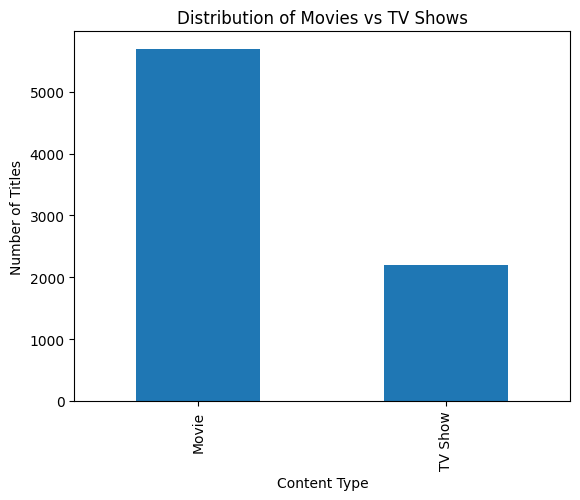

In [ ]:
#visualization
import matplotlib.pyplot as plt

df["type"].value_counts().plot(kind="bar")

plt.title("Distribution of Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [33]:
#2. How has Netflix expanded its content catalog over time?
content_growth = df.groupby("year_added")["show_id"].count()

content_growth

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: show_id, dtype: int64

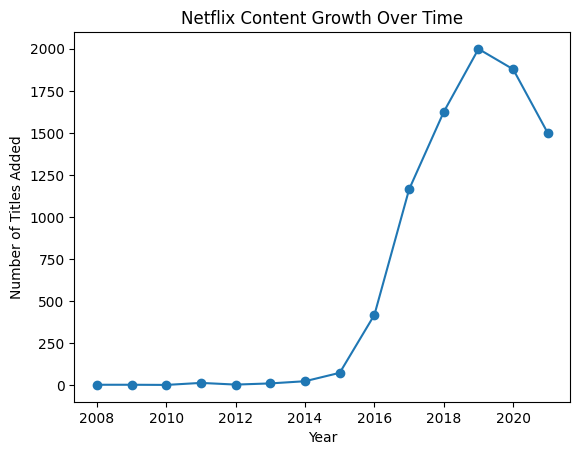

In [34]:
#visualization
content_growth.plot(kind="line", marker="o")

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.show()

In [56]:
#3 Which countries produce the most Netflix content?
df["country"].value_counts().head(10)

country
United States     2778
India              971
United Kingdom     403
Japan              241
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Egypt              106
Name: count, dtype: int64

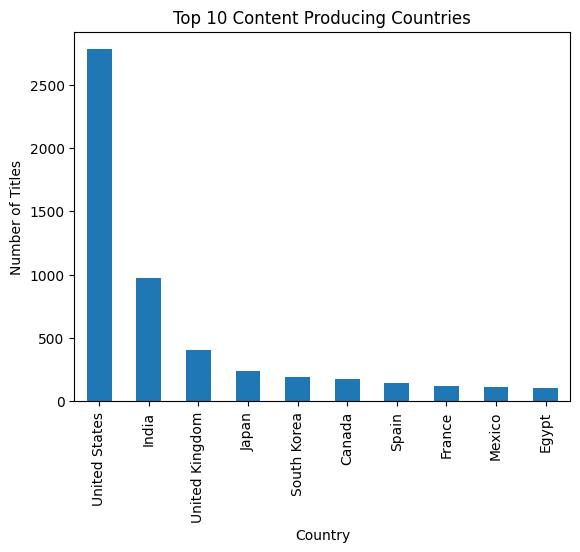

In [57]:
#visualization
df["country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

In [39]:
#What genres dominate the Netflix catalog?
df["listed_in"].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Children & Family Movies                            215
Kids' TV                                            212
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

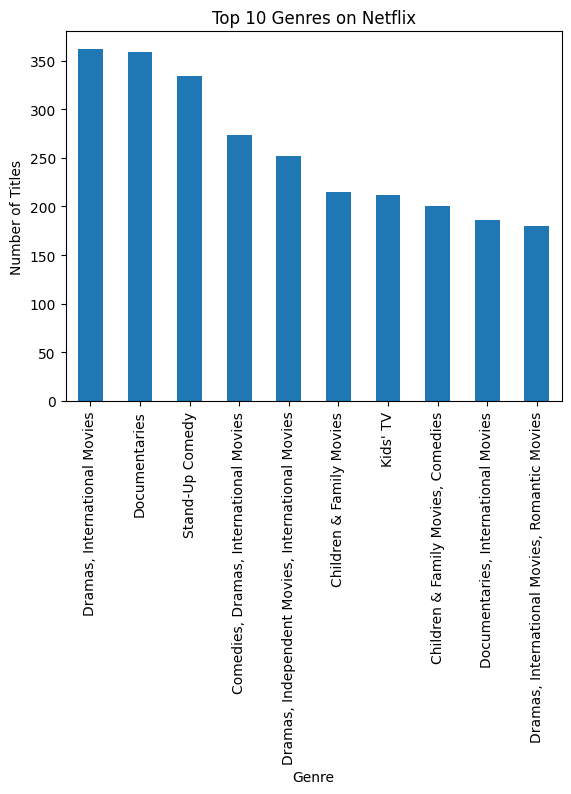

In [40]:
#visualization
df["listed_in"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.show()

In [41]:
#5. Which content ratings are most common?
df["rating"].value_counts()

rating
TV-MA       3183
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
Unknown        7
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

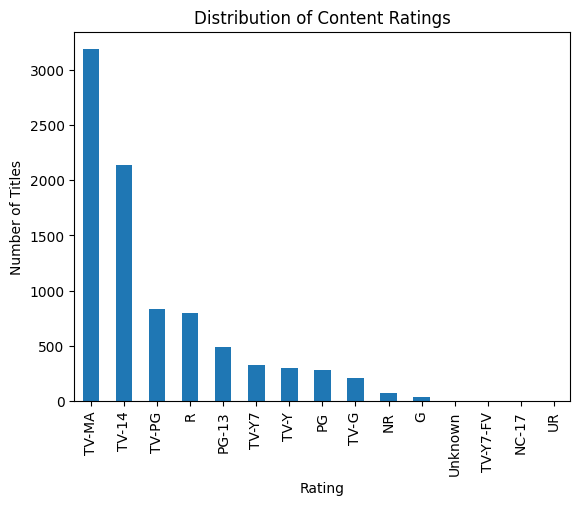

In [42]:
#visualization
df["rating"].value_counts().plot(kind="bar")

plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.show()

In [43]:
#What is the distribution of movie lengths?
movies = df[df["type"] == "Movie"]

movies["movie_duration_min"].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: movie_duration_min, dtype: float64

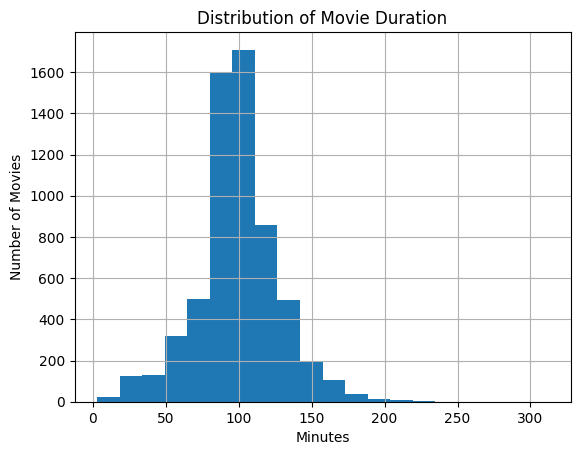

In [44]:
#visualization
movies["movie_duration_min"].hist(bins=20)

plt.title("Distribution of Movie Duration")
plt.xlabel("Minutes")
plt.ylabel("Number of Movies")

plt.show()

In [45]:
#7. How many seasons do Netflix TV shows typically have?
tv_shows = df[df["type"] == "TV Show"]

tv_shows["tv_seasons"].value_counts()

tv_seasons
1.0     1791
2.0      384
3.0      178
4.0       89
5.0       55
6.0       30
7.0       18
8.0       13
9.0        8
10.0       5
13.0       2
15.0       2
12.0       2
17.0       1
Name: count, dtype: int64

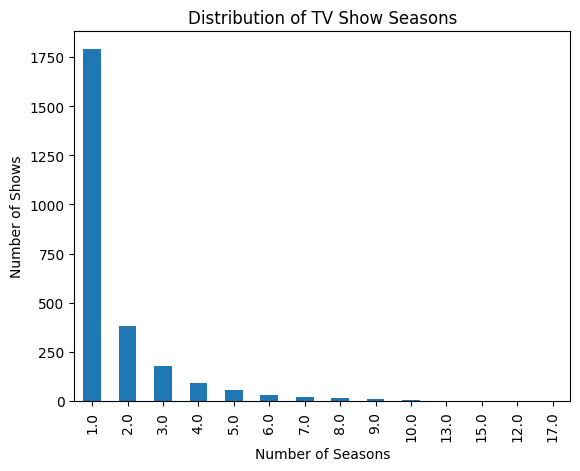

In [46]:
#visualization
tv_shows["tv_seasons"].value_counts().plot(kind="bar")

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Shows")

plt.show()

In [ ]:
## Key Insights

# Movies dominate Netflix's content catalog compared to TV shows.

# Netflix significantly expanded its content library after 2016.

# The United States produces the majority of Netflix content.

# Drama and international movies are among the most common genres.

# Most Netflix movies are between 90–120 minutes long.

# Most TV shows on Netflix have 1–3 seasons.

#removed unknown column from the data set for better understanding.